In [5]:
import os
from dotenv import load_dotenv
import databento as db
import pandas as pd
import numpy as np

load_dotenv()
client = db.Historical(os.environ.get("DATABENTO_API_KEY"))

In [ ]:
# !!!ONLY RUN IF THERE IS NO EXISTING DATA IN /data OR IF YOU WANT NEW DATA!!!
data = client.timeseries.get_range(
    dataset="XNAS.ITCH",
    symbols="INTC",
    schema="trades",
    start="2023-01-01",
    end="2026-01-01",
    path="../data/INTC_trades(XNASITCH).dbn.zst",
)

store = db.DBNStore.from_file("../data/INTC_trades(XNASITCH).dbn.zst")
store.to_parquet("../data/INTC_trades(XNASITCH).parquet")

In [15]:
# Define a daily_rv function that takes df and freq and returns a DataFrame with daily realized volatility

def clean_trades(raw, tz="America/New_York", start="09:30:00", end="16:00:00"):
    """Keep valid trades, index by exchange timestamp in local tz, restrict to RTH."""
    df = raw[(raw["price"] > 0) & (raw["size"] > 0)].copy()
    df = df.set_index("ts_event")
    df.index = df.index.tz_convert(tz)
    return df.between_time(start, end)

def daily_rv(df, freq):
    day = df.index.normalize()
    prices = (
        df["price"]
        .groupby(day)
        .resample(freq)
        .last()
        .groupby(level=0).ffill() #within-day only
        .droplevel(0)
    )

    #Get opening price for each day
    opens = df["price"].groupby(day).first()

    #Add openings to resampled prices
    prices = pd.concat([opens, prices]).sort_index()
    
    logp = np.log(prices)

    rv_daily = (
        logp.groupby(logp.index.normalize())
        .apply(lambda x: (x.diff() ** 2).sum())
    )

    return rv_daily

def bin_diagnostics(df, freq):
    """Why fine grids lose information, averaged across days.

    empty          : bins containing no trade (arrival staleness)
    unchanged      : sampled price equals the previous sample
    discretization : the difference — bins that traded but did not move
    """
    day = df.index.normalize()
    last = df["price"].groupby(day).resample(freq).last()

    empty = last.isna().groupby(level=0).mean().mean()

    filled = last.groupby(level=0).ffill().droplevel(0)
    fd = filled.index.normalize()
    unchanged = (
        filled.groupby(fd)
        .apply(lambda x: x.eq(x.shift(1)).iloc[1:].mean())
        .mean()
    )

    return pd.Series({"empty": empty,
                      "unchanged": unchanged,
                      "discretization": unchanged - empty})

In [16]:
# Create a df that contains the daily realized volatility for each frequency in freqs

freqs = ["100ms", "200ms", "500ms", "1s", "2s", "5s", "10s",
         "30s", "1min", "2min", "5min", "10min", "30min"]

parts, diags = [], []

for month in pd.date_range("2023-01", "2023-12", freq="MS", tz="UTC"):
    raw = pd.read_parquet(
        "../data/INTC_trades(XNASITCH).parquet",
        columns=["ts_event", "price", "size"],
        filters=[("ts_event", ">=", month),
                 ("ts_event", "<",  month + pd.offsets.MonthBegin(1))],
    )
    df = clean_trades(raw)

    parts.append(pd.DataFrame({f: daily_rv(df, f) for f in freqs}))
    diags.append(pd.DataFrame({f: bin_diagnostics(df, f) for f in freqs}).T)

    print(month.date(), len(df), "trades")

rv = pd.concat(parts)
diag = pd.concat(diags).groupby(level=0).mean().loc[freqs]

2023-01-01 679120 trades
2023-02-01 776936 trades
2023-03-01 1074206 trades
2023-04-01 745888 trades
2023-05-01 929441 trades
2023-06-01 1203796 trades
2023-07-01 785023 trades
2023-08-01 831908 trades
2023-09-01 961149 trades
2023-10-01 970398 trades
2023-11-01 865663 trades
2023-12-01 898623 trades


In [17]:
print(len(rv), "days\n")
print(diag.round(4))

# mean vs median across days — if the shape differs, a few days are driving it
sig = pd.DataFrame({"mean": rv.mean() * 252 * 100,
                    "median": rv.median() * 252 * 100})
print("\n", sig.round(2))

250 days

        empty  unchanged  discretization
100ms  0.9618     0.9804          0.0186
200ms  0.9287     0.9625          0.0337
500ms  0.8430     0.9135          0.0705
1s     0.7279     0.8433          0.1155
2s     0.5594     0.7316          0.1721
5s     0.2859     0.5202          0.2342
10s    0.1139     0.3500          0.2361
30s    0.0086     0.1659          0.1572
1min   0.0028     0.1074          0.1046
2min   0.0022     0.0735          0.0714
5min   0.0013     0.0484          0.0470
10min  0.0007     0.0316          0.0308
30min  0.0000     0.0198          0.0198

        mean  median
100ms  7.52    6.14
200ms  7.65    6.25
500ms  7.87    6.42
1s     8.14    6.60
2s     8.44    6.85
5s     8.75    7.21
10s    9.00    7.30
30s    9.39    7.33
1min   9.50    7.57
2min   9.37    7.29
5min   9.71    7.52
10min  9.35    7.58
30min  9.70    6.91


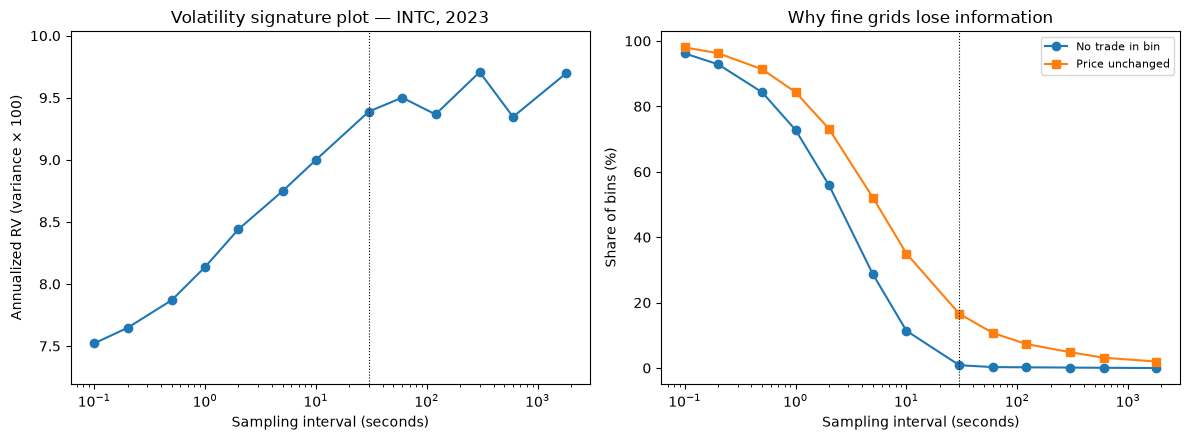

In [18]:
import matplotlib.pyplot as plt

seconds = [0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120, 300, 600, 1800]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].semilogx(seconds, rv.mean() * 252 * 100, marker="o")
ax[0].axvline(30, color="k", ls=":", lw=0.8)
ax[0].margins(y=0.15)
ax[0].set_title("Volatility signature plot — INTC, 2023")
ax[0].set_xlabel("Sampling interval (seconds)")
ax[0].set_ylabel("Annualized RV (variance × 100)")

ax[1].semilogx(seconds, 100 * diag["empty"], marker="o", label="No trade in bin")
ax[1].semilogx(seconds, 100 * diag["unchanged"], marker="s", label="Price unchanged")
ax[1].axvline(30, color="k", ls=":", lw=0.8)
ax[1].set_title("Why fine grids lose information")
ax[1].set_xlabel("Sampling interval (seconds)")
ax[1].set_ylabel("Share of bins (%)")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()